# Pipeline de ingestão ate a camada prata de dados de CyberSecurity

## 1 Importações e organização de diretorio

In [1]:
%pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Os CSVs de ingestão devem ser postos em data/origin

In [3]:
# Criar as pastas data e subpastas
os.makedirs("../data/bronze", exist_ok=True)
os.makedirs("../data/origin", exist_ok=True) 
os.makedirs("../data/silver", exist_ok=True)

## 2 Ingestão

In [4]:
# Caminho dos arquivos
ORIGIN_PATH = pathlib.Path("../data/origin")
BRONZE_PATH = pathlib.Path("../data/bronze")

Ingestão do csv de incidentes

In [7]:
df_incidents = pd.read_csv(ORIGIN_PATH / "incidents_master.csv")

In [8]:
# Modificar df_incidents: colocar nomes das colunas em maiúsculo e adicionar novas colunas de data e fonte de ingestão.
df_incidents.columns = df_incidents.columns.str.upper()
df_incidents["INGESTION_DATE"] = pd.to_datetime("today").date()
df_incidents["INGESTION_SOURCE"] = "incidents_master.csv"

In [9]:
df_incidents.to_parquet(BRONZE_PATH / "incidents.parquet", index=False)

Ingestão de market_impact.csv

In [10]:
df_market = pd.read_csv(ORIGIN_PATH / "market_impact.csv")

In [11]:
# Modificar df_incidents: colocar nomes das colunas em maiúsculo e adicionar novas colunas de data e fonte de ingestão.
df_market.columns = df_market.columns.str.upper()
df_market["INGESTION_DATE"] = pd.to_datetime("today").date()
df_market["INGESTION_SOURCE"] = "market_impact.csv"

In [12]:
df_market.to_parquet(BRONZE_PATH / "market_impact.parquet", index=False)

Ingestão de financial_impact.csv

In [13]:
df_financial = pd.read_csv(ORIGIN_PATH / "financial_impact.csv")

In [14]:
# Modificar df_incidents: colocar nomes das colunas em maiúsculo e adicionar novas colunas de data e fonte de ingestão.
df_financial.columns = df_financial.columns.str.upper()
df_financial["INGESTION_DATE"] = pd.to_datetime("today").date()
df_financial["INGESTION_SOURCE"] = "financial_impact.csv"

In [15]:
df_financial.to_parquet(BRONZE_PATH / "financial_impact.parquet", index=False)

## 3 Analise de dados

#### analise de incidentes

In [16]:
df_incidents_bronze = pd.read_parquet(BRONZE_PATH / "incidents.parquet")

In [17]:
df_incidents_bronze.isnull().sum()

INCIDENT_ID                   0
COMPANY_NAME                  0
COMPANY_REVENUE_USD           0
COUNTRY_HQ                    0
INDUSTRY_PRIMARY              0
INDUSTRY_SECONDARY          697
EMPLOYEE_COUNT                0
IS_PUBLIC_COMPANY             0
STOCK_TICKER                438
INCIDENT_DATE                 0
INCIDENT_DATE_ESTIMATED       0
DISCOVERY_DATE                0
DISCLOSURE_DATE               0
ATTACK_VECTOR_PRIMARY         0
ATTACK_VECTOR_SECONDARY     639
ATTACK_CHAIN                275
ATTRIBUTED_GROUP            368
ATTRIBUTION_CONFIDENCE      368
DATA_COMPROMISED_RECORDS    248
DATA_TYPE                   248
SYSTEMS_AFFECTED              0
DOWNTIME_HOURS              430
DATA_SOURCE_PRIMARY           0
DATA_SOURCE_SECONDARY       464
DATA_SOURCE_TYPE              0
CONFIDENCE_TIER               0
QUALITY_SCORE                 0
QUALITY_GRADE                 0
REVIEW_FLAG                 780
NOTES                       636
CREATED_AT                    0
UPDATED_

In [18]:
duplicados_id = df_incidents_bronze["INCIDENT_ID"].duplicated().sum()
print(f"\nIDs de incidente repetidos: {duplicados_id}")


IDs de incidente repetidos: 0


In [19]:
df_incidents_bronze.dtypes

INCIDENT_ID                     str
COMPANY_NAME                    str
COMPANY_REVENUE_USD         float64
COUNTRY_HQ                      str
INDUSTRY_PRIMARY                str
INDUSTRY_SECONDARY              str
EMPLOYEE_COUNT                int64
IS_PUBLIC_COMPANY              bool
STOCK_TICKER                    str
INCIDENT_DATE                   str
INCIDENT_DATE_ESTIMATED        bool
DISCOVERY_DATE                  str
DISCLOSURE_DATE                 str
ATTACK_VECTOR_PRIMARY           str
ATTACK_VECTOR_SECONDARY         str
ATTACK_CHAIN                    str
ATTRIBUTED_GROUP                str
ATTRIBUTION_CONFIDENCE          str
DATA_COMPROMISED_RECORDS    float64
DATA_TYPE                       str
SYSTEMS_AFFECTED                str
DOWNTIME_HOURS              float64
DATA_SOURCE_PRIMARY             str
DATA_SOURCE_SECONDARY           str
DATA_SOURCE_TYPE                str
CONFIDENCE_TIER               int64
QUALITY_SCORE               float64
QUALITY_GRADE               

In [20]:
df_incidents_bronze.describe()

,COMPANY_REVENUE_USD,EMPLOYEE_COUNT,DATA_COMPROMISED_RECORDS,DOWNTIME_HOURS,CONFIDENCE_TIER,QUALITY_SCORE
count,8.500000e+02,8.500000e+02,6.020000e+02,420.000000,850.000000,850.000000
mean,1.031337e+10,5.433418e+04,2.708462e+06,107.208762,2.215294,79.963047
std,2.106158e+10,1.266599e+05,2.978069e+07,184.645681,1.202472,12.209540
min,2.424181e+07,6.700000e+01,1.000000e+03,1.830000,1.000000,50.040000
25%,2.327545e+08,1.087000e+03,1.200500e+04,25.822500,1.000000,71.727500
50%,1.261375e+09,6.219500e+03,5.613300e+04,53.600000,2.000000,80.815000
75%,8.692943e+09,4.359475e+04,2.891170e+05,119.800000,3.000000,90.072500
max,1.488980e+11,1.411332e+06,5.497365e+08,1951.620000,4.000000,99.780000


#### análise de market_impact

In [21]:
df_market_bronze = pd.read_parquet(BRONZE_PATH / "market_impact.parquet")

In [22]:
df_market_bronze.isnull().sum()

INCIDENT_ID                          0
STOCK_TICKER                         0
PRICE_7D_BEFORE                      0
PRICE_DISCLOSURE_DAY                 0
PRICE_1D_AFTER                       0
PRICE_7D_AFTER                       0
PRICE_30D_AFTER                      0
VOLUME_AVG_30D_BASELINE              0
VOLUME_DISCLOSURE_DAY                0
SECTOR_INDEX                         0
SECTOR_RETURN_SAME_PERIOD            0
ABNORMAL_RETURN_1D                   0
ABNORMAL_RETURN_7D                   0
ABNORMAL_RETURN_30D                  0
CAR_NEG1_TO_POS1                     0
CAR_0_TO_7                           0
CAR_0_TO_30                          0
CAR_0_TO_90                          0
T_STATISTIC_1D                       0
P_VALUE_1D                           0
T_STATISTIC_30D                      0
P_VALUE_30D                          0
EARNINGS_ANNOUNCEMENT_WITHIN_7D      0
MARKET_CAP_AT_DISCLOSURE             0
VOLUME_RATIO_DISCLOSURE              0
PRE_INCIDENT_VOLATILITY_3

In [23]:
duplicados_id_market = df_market_bronze["INCIDENT_ID"].duplicated().sum()
print(f"\nIDs de incidente repetidos em market_impact: {duplicados_id_market}")


IDs de incidente repetidos em market_impact: 0


In [24]:
df_market_bronze.dtypes

INCIDENT_ID                            str
STOCK_TICKER                           str
PRICE_7D_BEFORE                    float64
PRICE_DISCLOSURE_DAY               float64
PRICE_1D_AFTER                     float64
PRICE_7D_AFTER                     float64
PRICE_30D_AFTER                    float64
VOLUME_AVG_30D_BASELINE              int64
VOLUME_DISCLOSURE_DAY                int64
SECTOR_INDEX                           str
SECTOR_RETURN_SAME_PERIOD          float64
ABNORMAL_RETURN_1D                 float64
ABNORMAL_RETURN_7D                 float64
ABNORMAL_RETURN_30D                float64
CAR_NEG1_TO_POS1                   float64
CAR_0_TO_7                         float64
CAR_0_TO_30                        float64
CAR_0_TO_90                        float64
T_STATISTIC_1D                     float64
P_VALUE_1D                         float64
T_STATISTIC_30D                    float64
P_VALUE_30D                        float64
EARNINGS_ANNOUNCEMENT_WITHIN_7D       bool
MARKET_CAP_

In [25]:
df_market_bronze.describe()

,PRICE_7D_BEFORE,PRICE_DISCLOSURE_DAY,PRICE_1D_AFTER,PRICE_7D_AFTER,PRICE_30D_AFTER,VOLUME_AVG_30D_BASELINE,VOLUME_DISCLOSURE_DAY,SECTOR_RETURN_SAME_PERIOD,ABNORMAL_RETURN_1D,ABNORMAL_RETURN_7D,...,CAR_0_TO_90,T_STATISTIC_1D,P_VALUE_1D,T_STATISTIC_30D,P_VALUE_30D,MARKET_CAP_AT_DISCLOSURE,VOLUME_RATIO_DISCLOSURE,PRE_INCIDENT_VOLATILITY_30D,POST_INCIDENT_VOLATILITY_30D,DAYS_TO_PRICE_RECOVERY
count,358.000000,358.000000,358.000000,358.000000,358.000000,3.580000e+02,3.580000e+02,358.000000,358.000000,358.000000,...,358.000000,358.000000,358.000000,358.000000,358.000000,3.580000e+02,358.000000,358.000000,358.000000,322.000000
mean,129.015642,124.754832,120.293268,120.945279,122.503631,3.556234e+06,9.897671e+06,0.004747,-0.034183,-0.030746,...,-0.012242,-2.594621,0.662270,-1.020512,0.888135,7.796113e+10,2.746851,0.023778,0.037085,109.866460
std,175.589952,169.632368,163.316301,164.186311,166.319908,7.377916e+06,2.063455e+07,0.014757,0.022088,0.026497,...,0.021135,2.172606,0.401876,1.739969,0.258872,1.356710e+11,0.722342,0.008535,0.014843,103.606842
min,5.080000,5.000000,4.610000,4.790000,4.990000,2.746300e+04,8.053000e+04,-0.019971,-0.098128,-0.106112,...,-0.095579,-15.612200,0.000200,-10.355500,0.000200,9.267550e+07,1.508100,0.010135,0.011879,5.000000
25%,13.257500,12.657500,12.110000,12.122500,12.447500,4.439210e+05,1.188034e+06,-0.008347,-0.049536,-0.046946,...,-0.024614,-3.467100,0.266450,-1.911025,0.986000,3.086725e+09,2.114125,0.016342,0.024839,28.000000
50%,43.515000,42.535000,41.050000,40.850000,41.575000,1.166098e+06,3.107902e+06,0.004854,-0.031195,-0.028201,...,-0.010039,-2.167200,0.916400,-0.879650,1.000000,1.929513e+10,2.753400,0.023608,0.034480,57.000000
75%,155.650000,149.607500,148.205000,147.845000,148.980000,2.963769e+06,7.480774e+06,0.018737,-0.018867,-0.010302,...,0.003258,-1.153600,1.000000,0.046925,1.000000,9.017196e+10,3.351200,0.030760,0.047426,177.000000
max,743.830000,741.520000,731.690000,734.290000,753.190000,6.688953e+07,1.728628e+08,0.029954,0.009984,0.025921,...,0.038986,1.185600,1.000000,4.671000,1.000000,1.059593e+12,3.993300,0.039934,0.077072,363.000000


#### análise de financial_impact

In [26]:
df_financial_bronze = pd.read_parquet(BRONZE_PATH / "financial_impact.parquet")

In [27]:
df_financial_bronze.isnull().sum()

INCIDENT_ID                 0
DIRECT_LOSS_USD             0
DIRECT_LOSS_METHOD          0
RANSOM_DEMANDED_USD       572
RANSOM_PAID_USD           692
RANSOM_SOURCE             692
RECOVERY_COST_USD           0
LEGAL_FEES_USD              0
REGULATORY_FINE_USD       646
INSURANCE_PAYOUT_USD      343
TOTAL_LOSS_USD              0
TOTAL_LOSS_METHOD           0
TOTAL_LOSS_LOWER_BOUND      0
TOTAL_LOSS_UPPER_BOUND      0
INFLATION_ADJUSTED_USD      0
CPI_INDEX_USED              0
NOTES                     530
CREATED_AT                  0
UPDATED_AT                  0
INGESTION_DATE              0
INGESTION_SOURCE            0
dtype: int64

In [28]:
duplicados_id_financial = df_financial_bronze["INCIDENT_ID"].duplicated().sum()
print(f"\nIDs de incidente repetidos em financial_impact: {duplicados_id_financial}")


IDs de incidente repetidos em financial_impact: 0


In [29]:
df_financial_bronze.dtypes

INCIDENT_ID                   str
DIRECT_LOSS_USD           float64
DIRECT_LOSS_METHOD            str
RANSOM_DEMANDED_USD       float64
RANSOM_PAID_USD           float64
RANSOM_SOURCE                 str
RECOVERY_COST_USD         float64
LEGAL_FEES_USD            float64
REGULATORY_FINE_USD       float64
INSURANCE_PAYOUT_USD      float64
TOTAL_LOSS_USD            float64
TOTAL_LOSS_METHOD             str
TOTAL_LOSS_LOWER_BOUND    float64
TOTAL_LOSS_UPPER_BOUND    float64
INFLATION_ADJUSTED_USD    float64
CPI_INDEX_USED                str
NOTES                         str
CREATED_AT                    str
UPDATED_AT                    str
INGESTION_DATE             object
INGESTION_SOURCE              str
dtype: object

In [30]:
df_financial_bronze.describe()

,DIRECT_LOSS_USD,RANSOM_DEMANDED_USD,RANSOM_PAID_USD,RECOVERY_COST_USD,LEGAL_FEES_USD,REGULATORY_FINE_USD,INSURANCE_PAYOUT_USD,TOTAL_LOSS_USD,TOTAL_LOSS_LOWER_BOUND,TOTAL_LOSS_UPPER_BOUND,INFLATION_ADJUSTED_USD
count,7.780000e+02,2.060000e+02,8.600000e+01,7.780000e+02,7.780000e+02,1.320000e+02,4.350000e+02,7.780000e+02,7.780000e+02,7.780000e+02,7.780000e+02
mean,3.652294e+07,8.017672e+06,4.497464e+06,2.618556e+07,7.309469e+06,2.834303e+06,2.665044e+07,7.099600e+07,5.111886e+07,1.059982e+08,7.501910e+07
std,1.196191e+08,1.580389e+07,9.186802e+06,7.816093e+07,2.390878e+07,7.363815e+06,7.593903e+07,2.151881e+08,1.471999e+08,3.283143e+08,2.233519e+08
min,9.000000e+04,5.000000e+04,1.610098e+04,5.703142e+04,1.276379e+04,5.000000e+04,6.280104e+04,1.737931e+05,1.256943e+05,2.752890e+05,1.737931e+05
25%,2.834239e+06,6.578965e+05,4.247265e+05,2.055169e+06,4.748212e+05,2.771979e+05,2.277000e+06,6.166441e+06,4.519930e+06,8.766029e+06,6.489252e+06
50%,8.525071e+06,1.979266e+06,1.129759e+06,6.129803e+06,1.506969e+06,9.141517e+05,6.316200e+06,1.656491e+07,1.185589e+07,2.534531e+07,1.790865e+07
75%,2.609037e+07,6.303181e+06,3.589926e+06,1.840980e+07,4.756604e+06,2.106179e+06,1.844803e+07,5.259585e+07,3.786537e+07,7.729790e+07,5.589355e+07
max,2.302300e+09,7.500000e+07,5.188418e+07,1.238193e+09,3.828183e+08,5.114644e+07,1.054416e+09,3.451548e+09,2.108922e+09,5.872051e+09,3.451548e+09


## 4 Tratamentos para a camada prata

#### Tratamento de incidentes

In [31]:
PRATA_PATH = pathlib.Path("../data/silver")

In [32]:
# convertendo as colunas de data para o formato datetime
date_cols = ["INCIDENT_DATE", "DISCOVERY_DATE", "DISCLOSURE_DATE", "INGESTION_DATE"]
for col in date_cols:
    df_incidents_bronze[col] = pd.to_datetime(df_incidents_bronze[col])

In [33]:
# Tratando strings nulas com Unknown quando fizer sentido;
categorical_cols = [
    "INDUSTRY_SECONDARY",
    "ATTACK_VECTOR_SECONDARY",
    "ATTRIBUTED_GROUP",
    "DATA_TYPE",
    "STOCK_TICKER",
    "REVIEW_FLAG",
    "ATTACK_CHAIN",
    "ATTRIBUTION_CONFIDENCE",
]
df_incidents_bronze[categorical_cols] = df_incidents_bronze[categorical_cols].fillna("Unknown")

In [34]:
# 0 para colunas numéricas onde a ausência de valor pode ser interpretada como 0.
df_incidents_bronze['DATA_COMPROMISED_RECORDS'] = df_incidents_bronze['DATA_COMPROMISED_RECORDS'].fillna(0)
df_incidents_bronze['DOWNTIME_HOURS'] = df_incidents_bronze['DOWNTIME_HOURS'].fillna(0)

In [35]:
# dropando colunas que não são úteis para a análise ou modelagem, como notas internas ou fontes de dados secundárias.
cols_realmente_ruins = ["NOTES", "DATA_SOURCE_SECONDARY", "CREATED_AT", "UPDATED_AT"]
df_incidents_bronze = df_incidents_bronze.drop(columns=cols_realmente_ruins, errors="ignore")

In [36]:
# dropando colunas que podem gerar Leakage .
cols_realmente_ruins = [
    "REGULATORY_FINE_USD",
    "INSURANCE_PAYOUT_USD",
    "DAYS_TO_PRICE_RECOVERY",
    "ABNORMAL_RETURN_30D",
]
df_incidents_bronze = df_incidents_bronze.drop(
    columns=cols_realmente_ruins, errors="ignore"
)

In [37]:
df_incidents_bronze.head(5)

,INCIDENT_ID,COMPANY_NAME,COMPANY_REVENUE_USD,COUNTRY_HQ,INDUSTRY_PRIMARY,INDUSTRY_SECONDARY,EMPLOYEE_COUNT,IS_PUBLIC_COMPANY,STOCK_TICKER,INCIDENT_DATE,...,SYSTEMS_AFFECTED,DOWNTIME_HOURS,DATA_SOURCE_PRIMARY,DATA_SOURCE_TYPE,CONFIDENCE_TIER,QUALITY_SCORE,QUALITY_GRADE,REVIEW_FLAG,INGESTION_DATE,INGESTION_SOURCE
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,"payment_systems,HR_systems",16.52,https://www.sec.gov/cgi-bin/browse-edgar?actio...,sec_filing,1,97.89,Gold,Unknown,2026-04-06,incidents_master.csv
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,Unknown,250,False,Unknown,2025-12-11,...,"file_servers,backup_systems,HR_systems,ERP",0.00,https://www.theregister.com/2025/06/14/quantum...,verified_media,3,86.74,Gold,Unknown,2026-04-06,incidents_master.csv
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,Unknown,71369,True,BITW,2023-01-15,...,HR_systems,0.00,https://therecord.media/2023/12/10/bitwire-inn...,verified_media,4,83.74,Silver,Unknown,2026-04-06,incidents_master.csv
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,Unknown,912,True,SFM,2021-03-15,...,"HR_systems,CRM,VPN",0.00,https://www.sterling-forge-markets-ho.com/news...,company_pr,2,94.51,Gold,Unknown,2026-04-06,incidents_master.csv
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,Unknown,1662,True,SQI,2021-12-04,...,"SCADA,VPN",0.00,https://www.sierra-quantum-innovation.com/news...,company_pr,2,79.82,Silver,Unknown,2026-04-06,incidents_master.csv


In [38]:
# criando a coluna target_severidade, onde 1 indica um incidente de alta severidade (downtime > 0 ou mais registros comprometidos que a mediana) e 0 caso contrário.
mediana_records = df_incidents_bronze["DATA_COMPROMISED_RECORDS"].median()
df_incidents_bronze["target_severidade"] = (
    (df_incidents_bronze["DOWNTIME_HOURS"] > 0)
    | (df_incidents_bronze["DATA_COMPROMISED_RECORDS"] > mediana_records)
).astype(int)

In [39]:
df_incidents_prata = df_incidents_bronze.copy()

In [40]:
df_incidents_prata.to_parquet(PRATA_PATH / "incidents_prata.parquet", index=False)

#### Tratamento de market

In [41]:
df_market_bronze.dtypes

INCIDENT_ID                            str
STOCK_TICKER                           str
PRICE_7D_BEFORE                    float64
PRICE_DISCLOSURE_DAY               float64
PRICE_1D_AFTER                     float64
PRICE_7D_AFTER                     float64
PRICE_30D_AFTER                    float64
VOLUME_AVG_30D_BASELINE              int64
VOLUME_DISCLOSURE_DAY                int64
SECTOR_INDEX                           str
SECTOR_RETURN_SAME_PERIOD          float64
ABNORMAL_RETURN_1D                 float64
ABNORMAL_RETURN_7D                 float64
ABNORMAL_RETURN_30D                float64
CAR_NEG1_TO_POS1                   float64
CAR_0_TO_7                         float64
CAR_0_TO_30                        float64
CAR_0_TO_90                        float64
T_STATISTIC_1D                     float64
P_VALUE_1D                         float64
T_STATISTIC_30D                    float64
P_VALUE_30D                        float64
EARNINGS_ANNOUNCEMENT_WITHIN_7D       bool
MARKET_CAP_

In [42]:
# 1. Lista de colunas de Leakage ou sem utilidade para análise/modelagem em market_impact.
cols_leakage_market = [
    "PRICE_7D_AFTER",
    "PRICE_30D_AFTER",
    "ABNORMAL_RETURN_7D",
    "ABNORMAL_RETURN_30D",
    "CAR_0_TO_7",
    "CAR_0_TO_30",
    "CAR_0_TO_90",
    "DAYS_TO_PRICE_RECOVERY",
    "NOTES",
    "POST_INCIDENT_VOLATILITY_30D",
    "T_STATISTIC_30D",
    "P_VALUE_30D",
    "CREATED_AT",
    "UPDATED_AT",
]

df_market_bronze = df_market_bronze.drop(columns=cols_leakage_market, errors="ignore")

In [43]:
# Convertendo a data de ingestão para o formato datetime
df_market_bronze["INGESTION_DATE"] = pd.to_datetime(df_market_bronze["INGESTION_DATE"])

In [44]:
print(df_market_bronze.dtypes)

INCIDENT_ID                                  str
STOCK_TICKER                                 str
PRICE_7D_BEFORE                          float64
PRICE_DISCLOSURE_DAY                     float64
PRICE_1D_AFTER                           float64
VOLUME_AVG_30D_BASELINE                    int64
VOLUME_DISCLOSURE_DAY                      int64
SECTOR_INDEX                                 str
SECTOR_RETURN_SAME_PERIOD                float64
ABNORMAL_RETURN_1D                       float64
CAR_NEG1_TO_POS1                         float64
T_STATISTIC_1D                           float64
P_VALUE_1D                               float64
EARNINGS_ANNOUNCEMENT_WITHIN_7D             bool
MARKET_CAP_AT_DISCLOSURE                 float64
VOLUME_RATIO_DISCLOSURE                  float64
PRE_INCIDENT_VOLATILITY_30D              float64
INGESTION_DATE                     datetime64[s]
INGESTION_SOURCE                             str
dtype: object


In [45]:
# Se a queda no dia 1 foi pior que -3%, marcamos como impacto alto (1)
df_market_bronze["target_market_impact"] = (
    df_market_bronze["ABNORMAL_RETURN_1D"] < -0.03
).astype(int)

In [46]:
# Removendo ABNORMAL_RETURN_1D para evitar leakage, já que o target é baseado nele
df_market_bronze = df_market_bronze.drop(columns=['ABNORMAL_RETURN_1D'], errors='ignore')

In [47]:
df_market_prata = df_market_bronze.copy()

In [48]:
df_market_prata.to_parquet(PRATA_PATH / "market_prata.parquet", index=False)

#### Tratamento de financial

In [49]:
df_financial_bronze = pd.read_parquet(BRONZE_PATH / "financial_impact.parquet")

In [50]:
# 1. Lista de colunas para remover (Leakage e Inúteis para o modelo)
cols_leakage_losses = [
    "RANSOM_PAID_USD",
    "RANSOM_SOURCE",
    "REGULATORY_FINE_USD",
    "INSURANCE_PAYOUT_USD",
    "NOTES",
    "CREATED_AT",
    "UPDATED_AT",
]
# 2. Aplicando o drop na Bronze para gerar a Prata
df_financial_bronze = df_financial_bronze.drop(
    columns=cols_leakage_losses, errors="ignore"
)

In [51]:
# Tratando RANSOM_DEMANDED_USD: Nulo vira 0 (Sem pedido de resgate)
df_financial_bronze["RANSOM_DEMANDED_USD"] = df_financial_bronze[
    "RANSOM_DEMANDED_USD"
].fillna(0)

In [52]:
mediana_perda = df_financial_bronze["TOTAL_LOSS_USD"].median()
df_financial_bronze["TARGET_SEVERE_LOSS"] = (
    df_financial_bronze["TOTAL_LOSS_USD"] > mediana_perda
).astype(int)

In [53]:
# Removendo colunas de perda total para evitar leakage do target
df_financial_bronze = df_financial_bronze.drop(columns=['TOTAL_LOSS_USD', 'TOTAL_LOSS_LOWER_BOUND', 'TOTAL_LOSS_UPPER_BOUND'], errors='ignore')

In [54]:
# Convertendo a data de ingestão para o formato datetime
df_financial_bronze["INGESTION_DATE"] = pd.to_datetime(df_financial_bronze["INGESTION_DATE"])

In [55]:
df_financial_prata = df_financial_bronze.copy()

In [56]:
df_financial_prata.to_parquet(PRATA_PATH / "financial_prata.parquet", index=False)

## 5 Análise Exploratória de Dados (EDA)

In [57]:
# Carregando datasets da camada prata para EDA
df_incidents_prata = pd.read_parquet(PRATA_PATH / "incidents_prata.parquet")
df_market_prata = pd.read_parquet(PRATA_PATH / "market_prata.parquet")
df_financial_prata = pd.read_parquet(PRATA_PATH / "financial_prata.parquet")

In [58]:
df_incidents_prata.head(5)

,INCIDENT_ID,COMPANY_NAME,COMPANY_REVENUE_USD,COUNTRY_HQ,INDUSTRY_PRIMARY,INDUSTRY_SECONDARY,EMPLOYEE_COUNT,IS_PUBLIC_COMPANY,STOCK_TICKER,INCIDENT_DATE,...,DOWNTIME_HOURS,DATA_SOURCE_PRIMARY,DATA_SOURCE_TYPE,CONFIDENCE_TIER,QUALITY_SCORE,QUALITY_GRADE,REVIEW_FLAG,INGESTION_DATE,INGESTION_SOURCE,target_severidade
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,16.52,https://www.sec.gov/cgi-bin/browse-edgar?actio...,sec_filing,1,97.89,Gold,Unknown,2026-04-06,incidents_master.csv,1
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,Unknown,250,False,Unknown,2025-12-11,...,0.00,https://www.theregister.com/2025/06/14/quantum...,verified_media,3,86.74,Gold,Unknown,2026-04-06,incidents_master.csv,1
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,Unknown,71369,True,BITW,2023-01-15,...,0.00,https://therecord.media/2023/12/10/bitwire-inn...,verified_media,4,83.74,Silver,Unknown,2026-04-06,incidents_master.csv,0
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,Unknown,912,True,SFM,2021-03-15,...,0.00,https://www.sterling-forge-markets-ho.com/news...,company_pr,2,94.51,Gold,Unknown,2026-04-06,incidents_master.csv,1
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,Unknown,1662,True,SQI,2021-12-04,...,0.00,https://www.sierra-quantum-innovation.com/news...,company_pr,2,79.82,Silver,Unknown,2026-04-06,incidents_master.csv,1


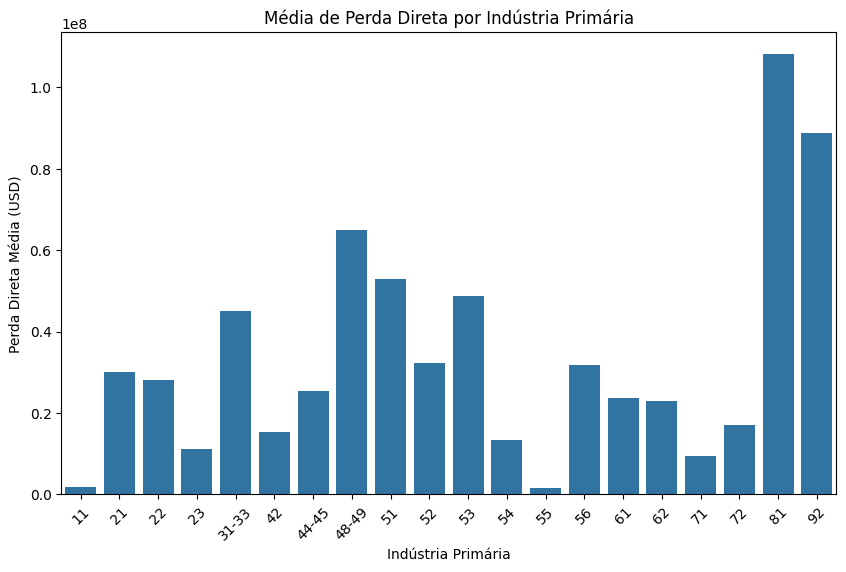

In [59]:
# Visualização 1: Média de perda direta por indústria primária (join incidents + financial)
df_merged = pd.merge(df_incidents_prata, df_financial_prata, on='INCIDENT_ID', how='inner')
loss_by_industry = df_merged.groupby('INDUSTRY_PRIMARY')['DIRECT_LOSS_USD'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=loss_by_industry, x='INDUSTRY_PRIMARY', y='DIRECT_LOSS_USD')
plt.title('Média de Perda Direta por Indústria Primária')
plt.xlabel('Indústria Primária')
plt.ylabel('Perda Direta Média (USD)')
plt.xticks(rotation=45)
plt.show()

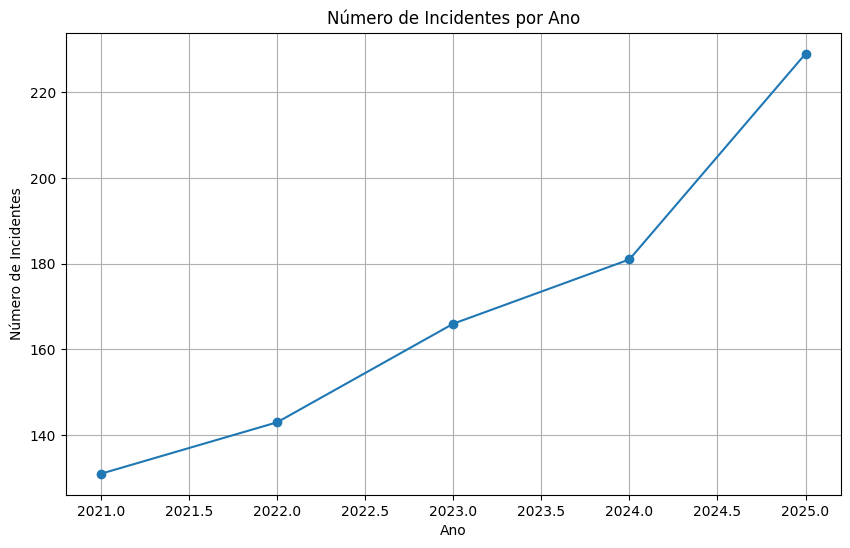

In [60]:
# Visualização 2: Série temporal de incidentes por data
df_incidents_prata['INCIDENT_DATE'] = pd.to_datetime(df_incidents_prata['INCIDENT_DATE'])
incidents_by_date = df_incidents_prata.groupby(df_incidents_prata['INCIDENT_DATE'].dt.year).size()
plt.figure(figsize=(10, 6))
incidents_by_date.plot(kind='line', marker='o')
plt.title('Número de Incidentes por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Incidentes')
plt.grid(True)
plt.show()

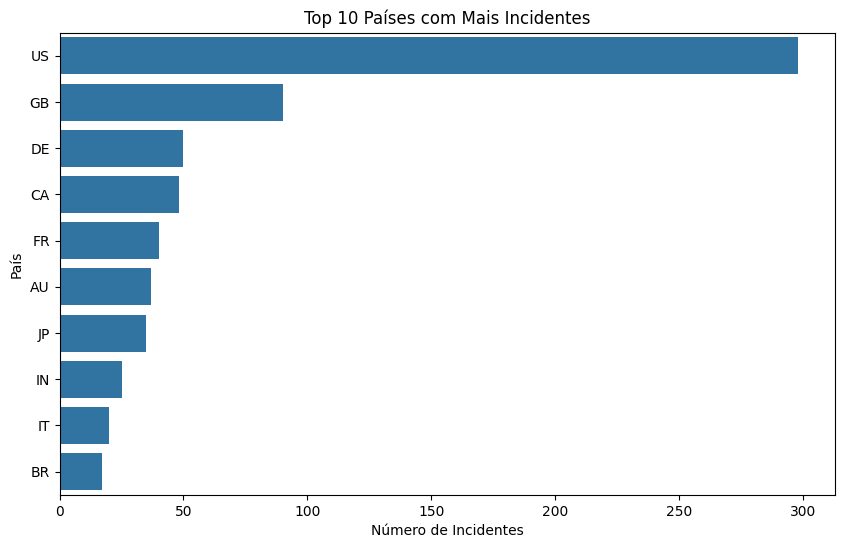

In [61]:
# Visualização 3: Top 10 países com mais incidentes
top_countries = df_incidents_prata['COUNTRY_HQ'].value_counts().head(10).reset_index()
top_countries.columns = ['País', 'Número de Incidentes']
plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries, x='Número de Incidentes', y='País')
plt.title('Top 10 Países com Mais Incidentes')
plt.xlabel('Número de Incidentes')
plt.ylabel('País')
plt.show()

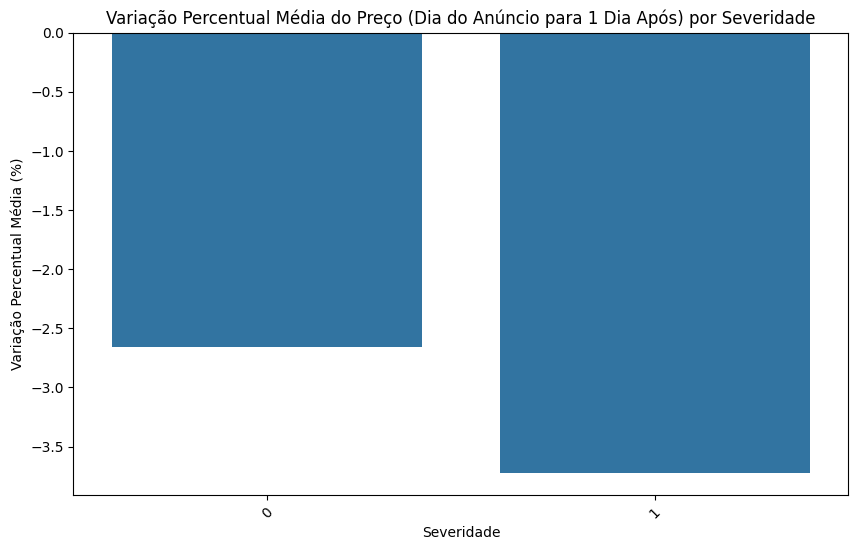

In [62]:
# Visualização 4: Variação percentual média do preço (dia do anúncio para 1 dia após) por severidade
df_merged_market = pd.merge(df_incidents_prata, df_market_prata, on='INCIDENT_ID', how='inner')
df_merged_market['price_change_pct'] = ((df_merged_market['PRICE_1D_AFTER'] - df_merged_market['PRICE_DISCLOSURE_DAY']) / df_merged_market['PRICE_DISCLOSURE_DAY']) * 100
avg_change_by_severity = df_merged_market.groupby('target_severidade')['price_change_pct'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_change_by_severity, x='target_severidade', y='price_change_pct')
plt.title('Variação Percentual Média do Preço (Dia do Anúncio para 1 Dia Após) por Severidade')
plt.xlabel('Severidade')
plt.ylabel('Variação Percentual Média (%)')
plt.xticks(rotation=45)
plt.show()